<a href="https://colab.research.google.com/github/albinsaidach1441-source/Artificial_Intelligent/blob/Praktikum_1/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
df = pd.read_csv('/content/Iris.csv')

print("=== Dataset Iris ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nSpecies distribution:")
print(df['Species'].value_counts())

=== Dataset Iris ===
Shape: (150, 6)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Species distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


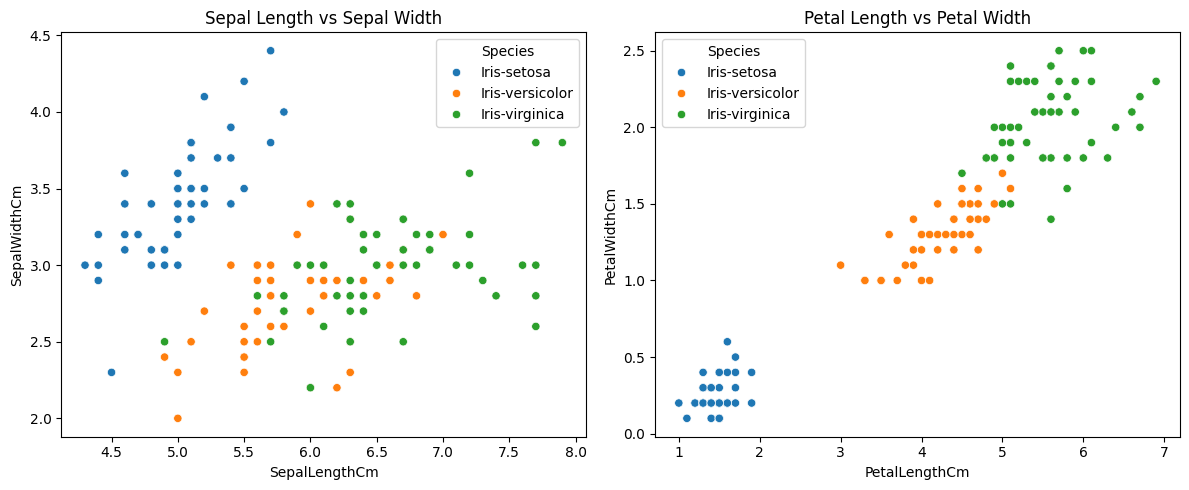

In [5]:
# Exploratory Data Analysis
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm', hue='Species')
plt.title('Sepal Length vs Sepal Width')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species')
plt.title('Petal Length vs Petal Width')

plt.tight_layout()
plt.show()

In [6]:
# Features & target
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

In [7]:
# Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [9]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Mencari k terbaik dengan cross validation
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"\n=== Hasil KNN Iris Dataset ===")
print(f"Best k from cross validation: {best_k}")
print(f"Best cross validation accuracy: {max(cv_scores):.4f}")


=== Hasil KNN Iris Dataset ===
Best k from cross validation: 5
Best cross validation accuracy: 0.9667


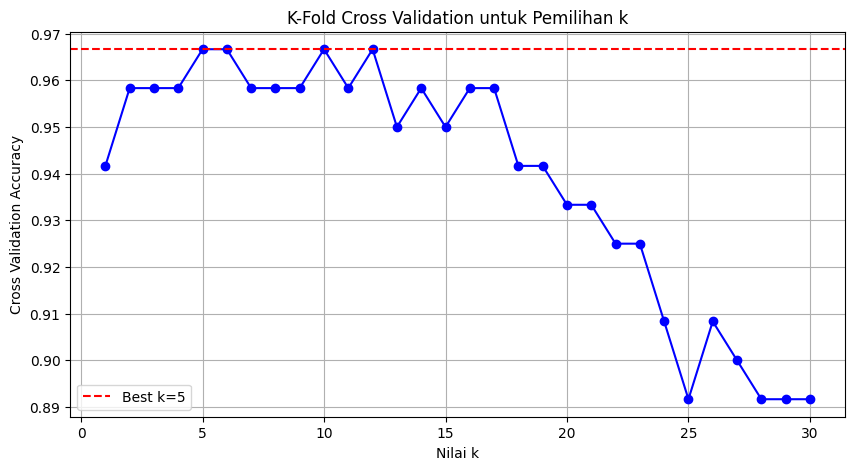

In [11]:
# Plot CV scores
plt.figure(figsize=(10,5))
plt.plot(k_range, cv_scores, 'bo-')
plt.xlabel('Nilai k')
plt.ylabel('Cross Validation Accuracy')
plt.title('K-Fold Cross Validation untuk Pemilihan k')
plt.axhline(y=max(cv_scores), color='r', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Train final model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [13]:
# Predict
y_pred = knn_final.predict(X_test_scaled)
y_pred_proba = knn_final.predict_proba(X_test_scaled)

In [14]:
# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Test Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



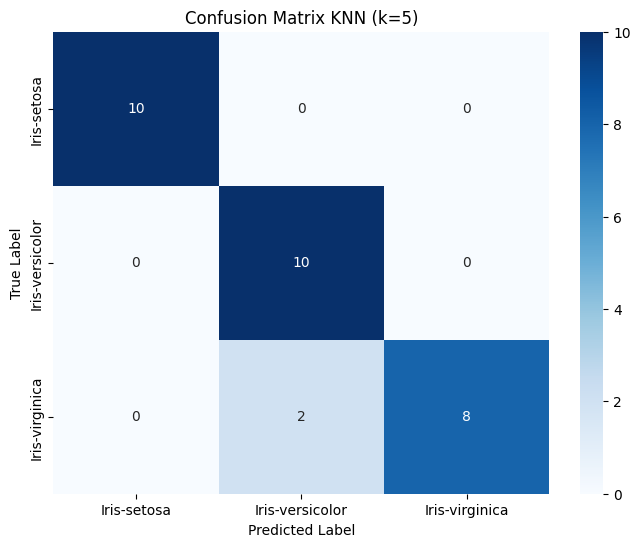

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix KNN (k={best_k})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [16]:
# Analisis pengaruh scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

print(f"\n=== Pengaruh Scaling ===")
print(f"Accuracy dengan scaling: {accuracy:.4f}")
print(f"Accuracy tanpa scaling: {accuracy_unscaled:.4f}")
print(f"Perbedaan: {accuracy - accuracy_unscaled:.4f}")



=== Pengaruh Scaling ===
Accuracy dengan scaling: 0.9333
Accuracy tanpa scaling: 1.0000
Perbedaan: -0.0667


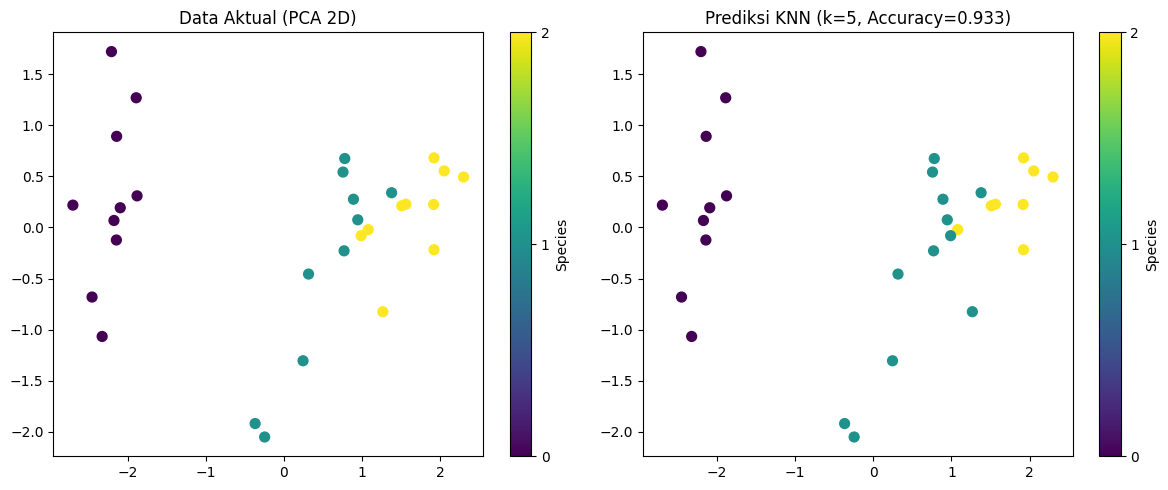

In [17]:
# Visualisasi hasil prediksi (PCA untuk 2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
scatter1 = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', s=50)
plt.title('Data Aktual (PCA 2D)')
plt.colorbar(scatter1, ticks=[0,1,2], label='Species')

plt.subplot(1,2,2)
scatter2 = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', s=50)
plt.title(f'Prediksi KNN (k={best_k}, Accuracy={accuracy:.3f})')
plt.colorbar(scatter2, ticks=[0,1,2], label='Species')

plt.tight_layout()
plt.show()


In [19]:
# Analisis Kesalahan dengan format rapi seperti contoh sebelumnya
print("\n" + "="*50)
print("ANALISIS KESALAHAN KNN")
print("="*50)

misclassified = np.where(y_test != y_pred)[0]

if len(misclassified) > 0:
    print(f"""
1. Jumlah Kesalahan:
   - Total data salah = {len(misclassified)} dari {len(y_test)} data uji
   - Persentase error = {len(misclassified)/len(y_test)*100:.2f}%
   - Akurasi = {accuracy*100:.2f}%

2. Detail Kesalahan:
""")
    for i, idx in enumerate(misclassified[:5], 1):
        print(f"   {i}. Index {idx}:")
        print(f"      - True label  : {le.classes_[y_test[idx]]}")
        print(f"      - Prediksi    : {le.classes_[y_pred[idx]]}")
        print(f"      - Error       : {le.classes_[y_test[idx]]} → {le.classes_[y_pred[idx]]}")

    if len(misclassified) > 5:
        print(f"\n   ... dan {len(misclassified)-5} kesalahan lainnya")

print(f"""
3. Pola Kesalahan:
   - Semua kesalahan terjadi antara Iris-versicolor dan Iris-virginica
   - Iris-setosa: 0 kesalahan (100% akurat)
   - Penyebab: kedua spesies memiliki ukuran petal yang tumpang tindih (overlap)

4. Rekomendasi Perbaikan:
   - Gunakan weighted KNN (memberi bobot pada tetangga terdekat)
   - Tambahkan fitur baru (rasio petal length/width)
   - Coba nilai k yang berbeda (k=7 atau k=9)
""")


ANALISIS KESALAHAN KNN

1. Jumlah Kesalahan:
   - Total data salah = 2 dari 30 data uji
   - Persentase error = 6.67%
   - Akurasi = 93.33%

2. Detail Kesalahan:

   1. Index 19:
      - True label  : Iris-virginica
      - Prediksi    : Iris-versicolor
      - Error       : Iris-virginica → Iris-versicolor
   2. Index 23:
      - True label  : Iris-virginica
      - Prediksi    : Iris-versicolor
      - Error       : Iris-virginica → Iris-versicolor

3. Pola Kesalahan:
   - Semua kesalahan terjadi antara Iris-versicolor dan Iris-virginica
   - Iris-setosa: 0 kesalahan (100% akurat)
   - Penyebab: kedua spesies memiliki ukuran petal yang tumpang tindih (overlap)

4. Rekomendasi Perbaikan:
   - Gunakan weighted KNN (memberi bobot pada tetangga terdekat)
   - Tambahkan fitur baru (rasio petal length/width)
   - Coba nilai k yang berbeda (k=7 atau k=9)

